<a href="https://colab.research.google.com/github/Haniiko1/CTL_Assay/blob/main/project_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 2

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import urllib.request
import os

### 1. Load Data

To begin, please specify the location and format of your protease assay data. For example, is it a CSV file, an Excel spreadsheet, or accessible via a database?

In [2]:
#@title  Upload your own CSV file from your computer


from google.colab import files
import re # Import regex module for column renaming

print("A file chooser dialog will appear below.")
print("Select your CSV file and wait for the upload to complete.")
print()

# This opens the file upload dialog
uploaded = files.upload()

# The filename is shown after upload completes
uploaded_filename = list(uploaded.keys())[0]

print(f"\n✅ File uploaded: {uploaded_filename}")

# Read the uploaded file into a DataFrame
df = pd.read_csv(uploaded_filename)

# Drop columns where all values are NaN directly after loading
df_cleaned = df.dropna(axis=1, how='all')

print(f"Original DataFrame shape: {df.shape}")
print(f"DataFrame shape after dropping all-NaN columns: {df_cleaned.shape}")

# Columns to remove further, including cycle number and temperature
columns_to_remove_further = ['Cycle Nr.', 'Temp. [°C]']

# Drop the specified columns from the already cleaned DataFrame
df_final = df_cleaned.drop(columns=columns_to_remove_further, errors='ignore')

# Convert 'Time [s]' to 'Time [min]' and make it a whole number
if 'Time [s]' in df_final.columns:
    df_final['Time [min]'] = (df_final['Time [s]'] / 60).astype(int)
    # Optionally, you might want to drop the original 'Time [s]' column
    df_final = df_final.drop(columns=['Time [s]'])

# Reorder columns to make 'Time [min]' the first column
if 'Time [min]' in df_final.columns:
    cols = df_final.columns.tolist()
    cols.remove('Time [min]')
    df_final = df_final[['Time [min]'] + cols]

# Rename columns to handle duplicates by appending _1, _2, etc.
# This assumes pandas has already added .1, .2 for actual duplicates during read_csv
original_columns = df_final.columns.tolist()
renamed_columns = []
counts = {} # To count occurrences of base names
suffix_counter = {} # To generate _1, _2, ... suffixes

# First pass to determine which base names are duplicated
for col in original_columns:
    # Strip any .N or _N suffix pandas might have added or that existed from prior runs
    # re.sub(pattern, replacement, text)
    # Find text matching pattern and replace it with replacement.
    # \.\d+|_\d+ means patterns with dot + numbers OR _ + numbers
    base_name = re.sub(r'(\.\d+|_\d+)$', '', col)
    counts[base_name] = counts.get(base_name, 0) + 1

# Second pass to apply renaming
for col in original_columns:
    base_name = re.sub(r'(\.\d+|_\d+)$', '', col)

    if counts[base_name] > 1:
        # If the base name is duplicated, apply a suffix to ALL occurrences
        suffix_counter[base_name] = suffix_counter.get(base_name, 0) + 1
        renamed_columns.append(f"{base_name}_{suffix_counter[base_name]}")
    else:
        # If the base name is unique, keep its name as is (it might be 'Time [min]' or a unique replicate name)
        renamed_columns.append(col)

df_final.columns = renamed_columns


print(f"Final DataFrame shape after removing '{columns_to_remove_further}' and converting time: {df_final.shape}")
print("Column names found in your file after all initial cleaning and time conversion:")
print(list(df_final.columns))
print()

print(f"Shape (final cleaned): {df_final.shape[0]} rows × {df_final.shape[1]} columns")
print()
print("Column names (final cleaned):")
print(list(df_final.columns))


# Replace NaN values with blank strings for display
display(df_final.fillna(''))



A file chooser dialog will appear below.
Select your CSV file and wait for the upload to complete.



Saving data1 - K12 RNAi Bmib.csv to data1 - K12 RNAi Bmib.csv

✅ File uploaded: data1 - K12 RNAi Bmib.csv
Original DataFrame shape: (90, 64)
DataFrame shape after dropping all-NaN columns: (90, 5)
Final DataFrame shape after removing '['Cycle Nr.', 'Temp. [°C]']' and converting time: (90, 3)
Column names found in your file after all initial cleaning and time conversion:
['Time [min]', 'K12 RNAi Bmib_1', 'K12 RNAi Bmib_2']

Shape (final cleaned): 90 rows × 3 columns

Column names (final cleaned):
['Time [min]', 'K12 RNAi Bmib_1', 'K12 RNAi Bmib_2']


,Time [min],K12 RNAi Bmib_1,K12 RNAi Bmib_2
0,0,10252,10193
1,2,9677,9852
2,4,9807,9628
3,6,9716,9487
4,8,9238,9357
...,...,...,...
85,170,9571,9667
86,172,9598,9659
87,174,9574,9664
88,176,9596,9661


In [31]:
#@title Find the minimum in each replicates, zero them, and find the overall maximum

print("--- Minimums of each sample (before zeroing) ---")

# Finding the minimum value in each sample
min_values = df_final.drop(columns=['Time [min]'], errors='ignore').min()
print(min_values)

# Get the list of columns to normalize (all except 'Time [min]')
columns_to_normalize = min_values.index.tolist()

# Subtract the minimum values from the corresponding columns in df_final
# We use .loc to ensure alignment by column names
df_final.loc[:, columns_to_normalize] = df_final.loc[:, columns_to_normalize].sub(min_values)

print("\n--- Data after zeroing samples ---")
display(df_final.fillna(''))

print("\n--- New maximums after subtracting baseline ---")
new_max_values = df_final.drop(columns=['Time [min]'], errors='ignore').max()
print(new_max_values)

print("\n--- The largest value among all new maximums ---")
print(new_max_values.max())

--- Minimums of each sample (before zeroing) ---
K12 RNAi Bmib_1    0
K12 RNAi Bmib_2    0
dtype: int64

--- Data after zeroing samples ---


,Time [min],K12 RNAi Bmib_1,K12 RNAi Bmib_2
0,0,1054,969
1,2,479,628
2,4,609,404
3,6,518,263
4,8,40,133
...,...,...,...
85,170,373,443
86,172,400,435
87,174,376,440
88,176,398,437



--- New maximums after subtracting baseline ---
K12 RNAi Bmib_1    1054
K12 RNAi Bmib_2     969
dtype: int64

--- The largest value among all new maximums ---
1054


In [8]:
#@title Normalize data to the overall maximum
overall_max = new_max_values.max()
print(f"Overall maximum value used for normalization: {overall_max}")

# Create a copy of df_final to store the normalized data
df_normalized = df_final.copy()

# Normalize all columns except 'Time [min]' by dividing by the overall maximum
columns_to_normalize = df_normalized.columns.drop('Time [min]', errors='ignore')
df_normalized[columns_to_normalize] = df_normalized[columns_to_normalize] / overall_max

print("\n--- Normalized DataFrame ---")
display(df_normalized)

Overall maximum value used for normalization: 1054

--- Normalized DataFrame ---


,Time [min],K12 RNAi Bmib_1,K12 RNAi Bmib_2
0,0,1.000000,0.919355
1,2,0.454459,0.595825
2,4,0.577799,0.383302
3,6,0.491461,0.249526
4,8,0.037951,0.126186
...,...,...,...
85,170,0.353890,0.420304
86,172,0.379507,0.412713
87,174,0.356736,0.417457
88,176,0.377609,0.414611


In [9]:
#@title Calculate Average and Standard Deviation per Replicate Group

# 1. Identify unique replicate groups (base names)
replicate_cols = df_normalized.columns.drop('Time [min]', errors='ignore')

# Extract unique base replicate names while preserving their order of first appearance
seen_base_reps = set()
base_replicates = []
for col in replicate_cols:
    # Strip postfixes from samples
    base_name = re.sub(r'(_\d+)$', '', col)
    if base_name not in seen_base_reps:
        base_replicates.append(base_name)
        seen_base_reps.add(base_name)

# Initialize a dictionary to hold all data, including MultiIndex keys
combined_data = {'Time [min]': df_normalized['Time [min]']}

# 2. Iterate through each base replicate group and calculate combined stats
for base_rep in base_replicates:
    # Find all columns in df_normalized that belong to this base_rep group
    group_cols = [col for col in replicate_cols if col.startswith(base_rep + '_') or col == base_rep]

    # Calculate the row-wise mean and standard deviation for these columns
    means = df_normalized[group_cols].mean(axis=1)
    stds = df_normalized[group_cols].std(axis=1).fillna(0)

    # Add to the combined_data dictionary with tuple keys for MultiIndex
    combined_data[(base_rep, 'Avg')] = means
    combined_data[(base_rep, 'Std Dev')] = stds

# Prepare the column tuples for the MultiIndex (for statistical columns only)
column_tuples_for_multiindex = []
for base_rep in base_replicates:
    column_tuples_for_multiindex.append((base_rep, 'Avg'))
    column_tuples_for_multiindex.append((base_rep, 'Std Dev'))

final_multi_index = pd.MultiIndex.from_tuples(column_tuples_for_multiindex)

# Create a dictionary containing only the MultiIndex-keyed Series for DataFrame construction
stats_data_for_df_construction = {}
for k, v in combined_data.items():
    if isinstance(k, tuple): # Select only the (base_rep, 'Avg'/'Std Dev') tuples
        stats_data_for_df_construction[k] = v

# Create the DataFrame from the statistical data
df_summary_stats_multiindex = pd.DataFrame(stats_data_for_df_construction)

# Ensure the columns are in the correct order and have the MultiIndex assigned
df_summary_stats_multiindex.columns = final_multi_index

# *** Apply x100 scaling to 'Avg' and 'Std Dev' columns and rename them ***
new_columns_for_multiindex = []
for col_tuple in df_summary_stats_multiindex.columns:
    if col_tuple[1] == 'Avg':
        # Scale the 'Avg' values
        df_summary_stats_multiindex[col_tuple] = df_summary_stats_multiindex[col_tuple] * 100
        # Create a new column tuple name for 'Avg'
        new_columns_for_multiindex.append((col_tuple[0], 'Avg (x100)'))
    elif col_tuple[1] == 'Std Dev':
        # Scale the 'Std Dev' values
        df_summary_stats_multiindex[col_tuple] = df_summary_stats_multiindex[col_tuple] * 100
        # Create a new column tuple name for 'Std Dev'
        new_columns_for_multiindex.append((col_tuple[0], 'Std Dev (x100)'))
    else:
        new_columns_for_multiindex.append(col_tuple)

df_summary_stats_multiindex.columns = pd.MultiIndex.from_tuples(new_columns_for_multiindex)

# Insert 'Time [min]' as the very first column with a single-level header
df_summary_stats_multiindex.insert(0, 'Time [min]', df_normalized['Time [min]'].values)

# Create a temporary DataFrame for display to explicitly format 'Time [min]' as string
df_display_temp = df_summary_stats_multiindex.copy()
df_display_temp['Time [min]'] = df_display_temp['Time [min]'].apply(lambda x: f'{x:.0f}') # Format as whole number


print("\n--- Average and Standard Deviation per Replicate Group --- ")
display(df_display_temp)


--- Average and Standard Deviation per Replicate Group --- 


Time [min] K12 RNAi Bmib               
                 Avg (x100) Std Dev (x100)
0           0     95.967742       5.702474
1           2     52.514231       9.996102
2           4     48.055028      13.753026
3           6     37.049336      17.107422
4           8      8.206831       6.239177
..        ...           ...            ...
85        170     38.709677       4.696155
86        172     39.611006       2.348078
87        174     38.709677       4.293628
88        176     39.611006       2.616429
89        178     40.749526       1.140495

[90 rows x 3 columns]

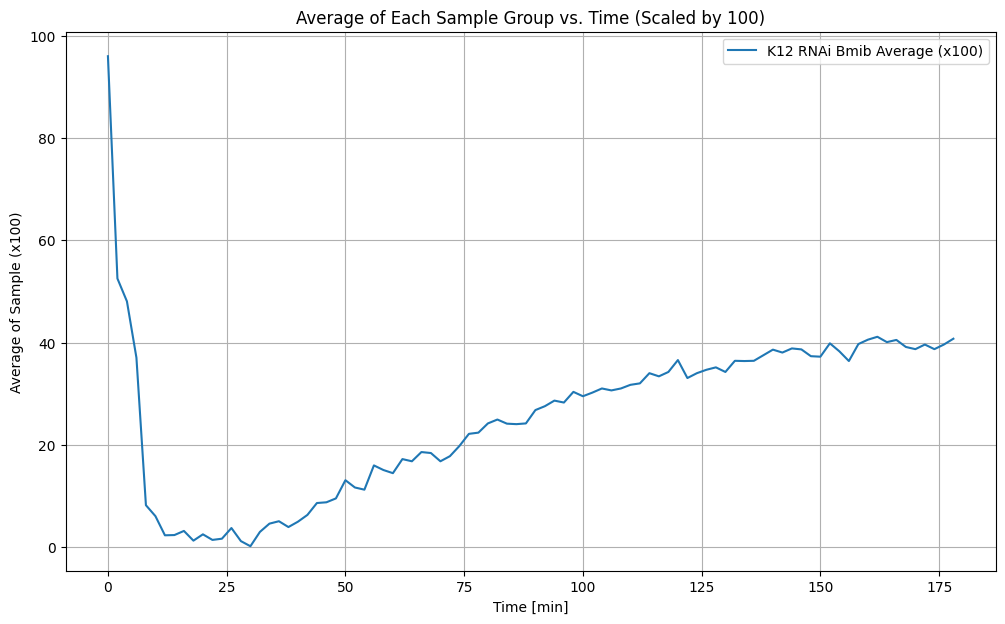

In [6]:
#@title Plot all data points

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

# Iterate through each base replicate to plot its 'Avg' against 'Time [min]'
for base_rep in base_replicates:
    # The 'Avg' column is already scaled and renamed in df_summary_stats_multiindex
    avg_col_name = (base_rep, 'Avg (x100)') # Use the new scaled column name
    plt.plot(df_summary_stats_multiindex['Time [min]'], df_summary_stats_multiindex[avg_col_name], label=f'{base_rep} Average (x100)')

plt.xlabel('Time [min]')
plt.ylabel('Average of Sample (x100)') # Keep y-axis label consistent with global scaling
plt.title('Average of Each Sample Group vs. Time (Scaled by 100)')
plt.legend()
plt.grid(True)
plt.show()

In [57]:
#@title Prompt user to input number of points each slice, show a table of $R^2$ and slope for each slice

from scipy import stats
import pandas as pd
from IPython.display import HTML, display # Import HTML for rich display

# Ensure df_summary_stats_multiindex is available and 'Time [min]' is numeric
# The df_summary_stats_multiindex from previous cells should be suitable for calculations

# Get user input for the number of points per slice
while True:
    try:
        points_per_slice_input = input("Enter the number of points for each slice (must be a positive integer, minimum 2): ")
        points_per_slice = int(points_per_slice_input)
        if points_per_slice < 2:
            print("Number of points per slice must be at least 2 for linear regression. Please try again.")
        else:
            break
    except ValueError:
        print("Invalid input. Please enter an integer.")

# Get user input for the stride (how many points the window should slide at each step)
while True:
    try:
        points_stride_input = input(f"Enter the number of points the window should slide for each step (e.g., 1 for 0-14, 2-16, ...; must be a positive integer): ")
        points_stride = int(points_stride_input)
        if points_stride < 1:
            print("Points stride must be at least 1. Please try again.")
        else:
            break
    except ValueError:
        print("Invalid input. Please enter an integer.")


# Initialize a list to store results
regression_results = []

num_rows = len(df_summary_stats_multiindex)

# Calculate number of slices for the sliding window
# The loop will go from start_idx = 0 up to (num_rows - points_per_slice)
# and increment by points_stride
# The actual number of slices is (num_rows - points_per_slice) // points_stride + 1
# if (num_rows - points_per_slice) % points_stride == 0, else it's slightly more complex.
# The range function handles this naturally.

# Iterate through each slice using a sliding window approach
# The loop generates start_idx for each slice
for start_idx in range(0, num_rows - points_per_slice + 1, points_stride):
    end_idx = start_idx + points_per_slice

    # Extract the slice of data
    slice_df = df_summary_stats_multiindex.iloc[start_idx:end_idx].copy()

    # Ensure 'Time [min]' is numeric (it should be from previous steps)
    x = slice_df['Time [min]'].astype(float)

    # Define the slice label for the table
    # Use .iloc[0] and .iloc[-1] to get the first and last Time [min] of the slice
    slice_start_time = x.iloc[0]
    slice_end_time = x.iloc[-1]
    slice_label = f'Slice (Time {slice_start_time:.0f}-{slice_end_time:.0f} min)'

    # Iterate through each base replicate group
    for base_rep in base_replicates:
        avg_col_name = (base_rep, 'Avg (x100)') # Use the scaled column name

        # Ensure 'Avg' column is numeric
        y = slice_df[avg_col_name].astype(float)

        # Perform linear regression
        # Check if there's enough data for regression in this slice
        if len(x) >= 2 and len(y) >= 2:
            # Use linregress for simple linear regression
            # slope, intercept, r_value, p_value, std_err
            slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)
            r_squared = r_value**2

            regression_results.append({
                'Slice': slice_label,
                'Replicate Group': base_rep,
                'R-squared': r_squared,
                'Slope': slope
            })
        else:
            print(f"Warning: Not enough data points in {slice_label} for {base_rep} to perform linear regression.")

# Create a DataFrame from the results
if regression_results:
    df_regression_summary = pd.DataFrame(regression_results)
    # Shows everything together

    # print("\n--- Linear Regression Analysis per Slice ---")
    # display(df_regression_summary.style.format({'R-squared': '{:.4f}', 'Slope': '{:.4f}'}))

    #Shows every samples individually

    print("\n--- Linear Regression Analysis per Slice ---")

    # Get unique replicate groups to display separate tables
    unique_replicate_groups = df_regression_summary['Replicate Group'].unique()

    all_tables_html = []
    for group in unique_replicate_groups:
        group_df = df_regression_summary[df_regression_summary['Replicate Group'] == group].drop(columns=['Replicate Group'])

        # Convert each styled DataFrame to HTML
        table_html = group_df.style.format({'R-squared': '{:.4f}', 'Slope': '{:.4f}'}).to_html(index=False)

        # Add a title above each table and wrap it in a div for layout
        all_tables_html.append(f'<div style="flex: 1; min-width: 300px; margin: 10px; border: 1px solid #ddd; padding: 10px;">')
        all_tables_html.append(f'<h4>Results for Replicate Group: {group}</h4>')
        all_tables_html.append(table_html)
        all_tables_html.append(f'</div>')

        # Commented out previous individual table display
        # print(f"\n--- Results for Replicate Group: {group} ---")
        # display(group_df.style.format({'R-squared': '{:.4f}', 'Slope': '{:.4f}'}))

    # Combine all individual table HTMLs into a single flex container
    combined_html = f'<div style="display: flex; flex-wrap: wrap; justify-content: flex-start;">{''.join(all_tables_html)}</div>'

    # Display the combined HTML
    display(HTML(combined_html))

else:
    print("No regression results to display. Please check your input and data.")

Enter the number of points for each slice (must be a positive integer, minimum 2): 72
Enter the number of points the window should slide for each step (e.g., 1 for 0-14, 2-16, ...; must be a positive integer): 1

--- Linear Regression Analysis per Slice ---


,Slice,R-squared,Slope
0,Slice (Time 0-142 min),0.2142,0.1772
1,Slice (Time 2-144 min),0.5068,0.2302
2,Slice (Time 4-146 min),0.6742,0.2585
3,Slice (Time 6-148 min),0.8437,0.2836
4,Slice (Time 8-150 min),0.9588,0.3024
5,Slice (Time 10-152 min),0.9653,0.3058
6,Slice (Time 12-154 min),0.9666,0.3065
7,Slice (Time 14-156 min),0.9617,0.3034
8,Slice (Time 16-158 min),0.9598,0.3017
9,Slice (Time 18-160 min),0.9583,0.3003


In [58]:
#@title Sort the time slices in decreasing slope order

import pandas as pd
from IPython.display import HTML, display # Import HTML for rich display

if 'df_regression_summary' in locals() and not df_regression_summary.empty:
    # Sort the DataFrame first by 'Slope' in descending order
    # Then by 'R-squared' in descending order for ties in Slope
    df_regression_summary_sorted = df_regression_summary.sort_values(
        by=['Slope', 'R-squared'], ascending=[False, False]
    ).copy() # Use .copy() to avoid SettingWithCopyWarning if modified later

    print("\n--- Linear Regression Analysis per Slice (Sorted) ---")

    # Get unique replicate groups from the sorted DataFrame
    current_unique_replicate_groups = df_regression_summary_sorted['Replicate Group'].unique()

    # Define the desired custom order
    custom_order = ['CB 15', 'CB 25', 'N2 15', 'N2 25']

    # Filter custom_order to include only groups actually present in the data
    ordered_replicate_groups = [group for group in custom_order if group in current_unique_replicate_groups]
    # Add any other groups not in custom_order to the end
    other_groups = [group for group in current_unique_replicate_groups if group not in custom_order]
    ordered_replicate_groups.extend(other_groups)

    all_tables_html = []
    for group in ordered_replicate_groups:
        # Filter the sorted DataFrame for the current group
        group_df = df_regression_summary_sorted[df_regression_summary_sorted['Replicate Group'] == group].drop(columns=['Replicate Group'])

        # Take only the top 5 rows
        group_df_top5 = group_df.head(5)

        # Convert each styled DataFrame to HTML
        table_html = group_df_top5.style.format({'R-squared': '{:.4f}', 'Slope': '{:.4f}'}).to_html(index=False)

        # Add a title above each table and wrap it in a div for layout
        all_tables_html.append(f'<div style="flex: 1; min-width: 300px; margin: 10px; border: 1px solid #ddd; padding: 10px;">')
        all_tables_html.append(f'<h4>Results for Replicate Group: {group} (Top 5)</h4>') # Updated title
        all_tables_html.append(table_html)
        all_tables_html.append(f'</div>')

    # Combine all individual table HTMLs into a single flex container
    combined_html = f'<div style="display: flex; flex-wrap: wrap; justify-content: flex-start;">{''.join(all_tables_html)}</div>'

    # Display the combined HTML
    display(HTML(combined_html))

else:
    print("df_regression_summary is not available or is empty. Please run the previous cell that generates it.")


--- Linear Regression Analysis per Slice (Sorted) ---


,Slice,R-squared,Slope
6,Slice (Time 12-154 min),0.9666,0.3065
5,Slice (Time 10-152 min),0.9653,0.3058
7,Slice (Time 14-156 min),0.9617,0.3034
4,Slice (Time 8-150 min),0.9588,0.3024
8,Slice (Time 16-158 min),0.9598,0.3017


In [59]:
#@title Sort the time slices in decreasing slope order ($R^2$ $>=$ $0.95$)

import pandas as pd
from IPython.display import HTML, display # Import HTML for rich display

H_P = '' # Initialize H_P. This variable is not used as a joiner, empty string is default for ''.join()

if 'df_regression_summary' in locals() and not df_regression_summary.empty:
    # --- Section 2: High R-squared Slices (Top 5, R-squared >= 0.95) ---
    print("\n--- Top 5 Linear Regression Slices per Group (R-squared >= 0.95) ---")

    # Get all unique replicate groups from the original summary (before filtering)
    all_original_replicate_groups = df_regression_summary['Replicate Group'].unique()

    # Filter for R-squared >= 0.95 first, then sort by slope and R-squared
    df_regression_summary_high_r_squared = df_regression_summary[
        df_regression_summary['R-squared'] >= 0.95
    ].sort_values(
        by=['Slope', 'R-squared'], ascending=[False, False]
    ).copy()

    # Define custom order
    custom_order = ['CB 15', 'CB 25', 'N2 15', 'N2 25'] # Example custom order

    # Prepare the ordered list of ALL replicate groups for display
    ordered_all_replicate_groups = [group for group in custom_order if group in all_original_replicate_groups]
    other_groups_all = [group for group in all_original_replicate_groups if group not in custom_order]
    ordered_all_replicate_groups.extend(other_groups_all)

    all_tables_html_high_r = []
    for group in ordered_all_replicate_groups:
        # Filter the high R-squared DataFrame for the current group
        group_df_high_r = df_regression_summary_high_r_squared[
            df_regression_summary_high_r_squared['Replicate Group'] == group
        ].drop(columns=['Replicate Group'])

        # Take the top 5 from this filtered and sorted group
        group_df_high_r_top5 = group_df_high_r.head(5)

        all_tables_html_high_r.append(f'<div style="flex: 1; min-width: 300px; margin: 10px; border: 1px solid #ddd; padding: 10px;">')
        all_tables_html_high_r.append(f'<h4>Results for Replicate Group: {group} (Top 5 - R-squared >= 0.95)</h4>')

        if not group_df_high_r_top5.empty: # Only generate HTML table if there are results
            table_html_high_r = group_df_high_r_top5.style.format({'R-squared': '{:.4f}', 'Slope': '{:.4f}'}).to_html(index=False)
            all_tables_html_high_r.append(table_html_high_r)
        else:
            # Explicitly state if a group has no slices meeting the criteria
            all_tables_html_high_r.append(f'<p>No slices found for this group with R-squared >= 0.95.</p>')
        all_tables_html_high_r.append(f'</div>')

    if all_tables_html_high_r: # Only display if there's content to show
        combined_html_high_r = f'<div style="display: flex; flex-wrap: wrap; justify: flex-start;">{" ".join(all_tables_html_high_r)}</div>'
        display(HTML(combined_html_high_r))
    else:
        print("No regression results (even with R-squared < 0.95) to process for any group.")

else:
    print("df_regression_summary is not available or is empty. Please run the cell that generates it (cell 9vWD_C4H10FI).")


--- Top 5 Linear Regression Slices per Group (R-squared >= 0.95) ---


,Slice,R-squared,Slope
6,Slice (Time 12-154 min),0.9666,0.3065
5,Slice (Time 10-152 min),0.9653,0.3058
7,Slice (Time 14-156 min),0.9617,0.3034
4,Slice (Time 8-150 min),0.9588,0.3024
8,Slice (Time 16-158 min),0.9598,0.3017


/tmp/ipykernel_691/1386283817.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  overall_colors = cm.get_cmap('tab10', len(all_replicate_groups))
/tmp/ipykernel_691/1386283817.py:45: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  slice_colors = cm.get_cmap('coolwarm', len(top_5_slices_for_group))


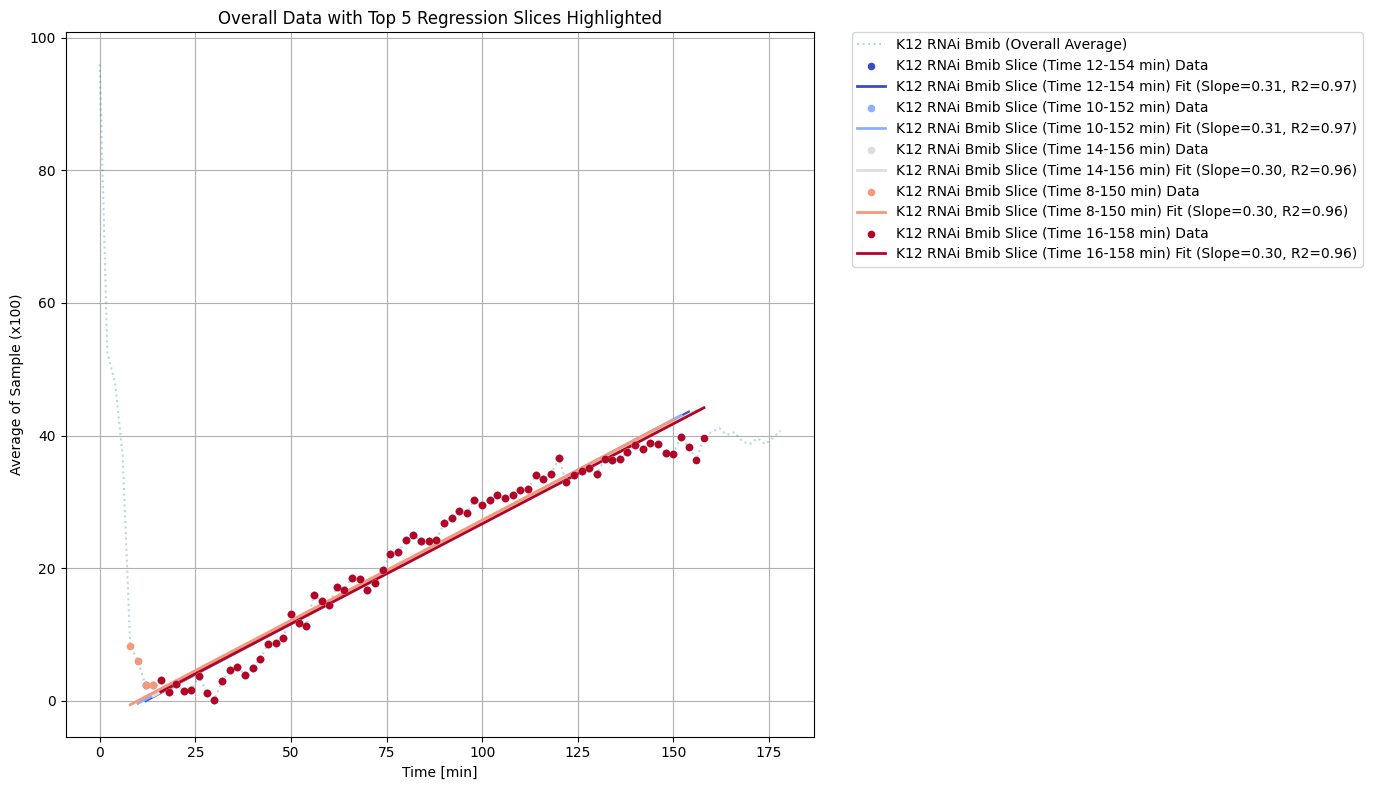

In [60]:
#@title Color coding the top 5 slopes on the overall graph

import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd
import numpy as np
import re
import matplotlib.cm as cm

# Ensure df_regression_summary_sorted and df_summary_stats_multiindex are available
if 'df_regression_summary_sorted' not in locals() or df_regression_summary_sorted.empty:
    print("Error: df_regression_summary_sorted is not available or is empty. Please run the previous cells.")
else:
    plt.figure(figsize=(14, 8))
    plt.title('Overall Data with Top 5 Regression Slices Highlighted')
    plt.xlabel('Time [min]')
    plt.ylabel('Average of Sample (x100)')
    plt.grid(True)

    # Get a list of all unique replicate groups
    all_replicate_groups = df_summary_stats_multiindex.columns.get_level_values(0).unique()
    # Exclude 'Time [min]' if it's treated as a level 0 column, which it shouldn't be for this logic
    if 'Time [min]' in all_replicate_groups:
        all_replicate_groups = all_replicate_groups.drop('Time [min]')

    # Generate a colormap for each overall replicate group (for background lines)
    overall_colors = cm.get_cmap('tab10', len(all_replicate_groups))

    # First, plot all overall average data points as a faint background
    for group_idx, base_rep in enumerate(all_replicate_groups):
        avg_col_name = (base_rep, 'Avg (x100)')
        plt.plot(df_summary_stats_multiindex['Time [min]'], df_summary_stats_multiindex[avg_col_name],
                 color=overall_colors(group_idx), linestyle=':', alpha=0.3, label=f'{base_rep} (Overall Average)')

    # Now, iterate through each replicate group and highlight its top 5 slopes
    for base_rep in all_replicate_groups:
        # Filter the sorted summary for the current group and take the top 5
        top_5_slices_for_group = df_regression_summary_sorted[
            df_regression_summary_sorted['Replicate Group'] == base_rep
        ].head(5)

        if not top_5_slices_for_group.empty:
            # Get a colormap for distinct colors for the 5 slices within this group
            # Using a different colormap or a different range from the same colormap
            slice_colors = cm.get_cmap('coolwarm', len(top_5_slices_for_group))

            for i, (index, row) in enumerate(top_5_slices_for_group.iterrows()):
                slice_label = row['Slice']
                slope_from_summary = row['Slope']
                r_squared_from_summary = row['R-squared']

                # Extract start and end time from slice_label
                time_match = re.search(r'Time (\d+)-(\d+) min', slice_label)
                if time_match:
                    start_time = int(time_match.group(1))
                    end_time = int(time_match.group(2))
                else:
                    print(f"Warning: Could not parse slice time range from label '{slice_label}'. Skipping slice.")
                    continue

                # Ensure 'Time [min]' in df_summary_stats_multiindex is numeric
                df_summary_stats_multiindex['Time [min]'] = pd.to_numeric(df_summary_stats_multiindex['Time [min]'], errors='coerce')

                # Filter df_summary_stats_multiindex to get the data for the selected slice
                slice_data_for_plot = df_summary_stats_multiindex[
                    (df_summary_stats_multiindex['Time [min]'] >= start_time) &
                    (df_summary_stats_multiindex['Time [min]'] <= end_time)
                ].copy()

                x_data = slice_data_for_plot['Time [min]'].astype(float)
                y_data = slice_data_for_plot[(base_rep, 'Avg (x100)')].astype(float)

                if len(x_data) < 2 or len(y_data) < 2:
                    print(f"Error: Not enough data points to plot for slice {slice_label} of group {base_rep}.")
                    continue

                # Recalculate regression for the exact slice data for plotting accuracy
                # (using the slope from summary for consistency if desired, or recalculate if precision is key)
                slope, intercept, r_value, p_value, std_err = stats.linregress(x_data, y_data)
                r_squared = r_value**2

                # Generate the best-fit line
                x_fit = np.array([x_data.min(), x_data.max()])
                y_fit = slope * x_fit + intercept

                current_color = slice_colors(i / len(top_5_slices_for_group)) # Get distinct color for this slice

                # Plot the data points for the current slice
                plt.scatter(x_data, y_data, color=current_color, s=20, zorder=5, label=f'{base_rep} {slice_label} Data')

                # Plot the regression line for the current slice
                plt.plot(x_fit, y_fit, color=current_color, linestyle='-', linewidth=2, zorder=4,
                         label=f'{base_rep} {slice_label} Fit (Slope={slope:.2f}, R2={r_squared:.2f})')
        else:
            print(f"No top 5 slices to highlight for Replicate Group: {base_rep}")

    # Place legend outside the plot to avoid obscuring data
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    plt.tight_layout() # Adjust layout to prevent legend overlap
    plt.show()

/tmp/ipykernel_691/1828864814.py:53: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  slice_colors = cm.get_cmap('coolwarm', num_slices)


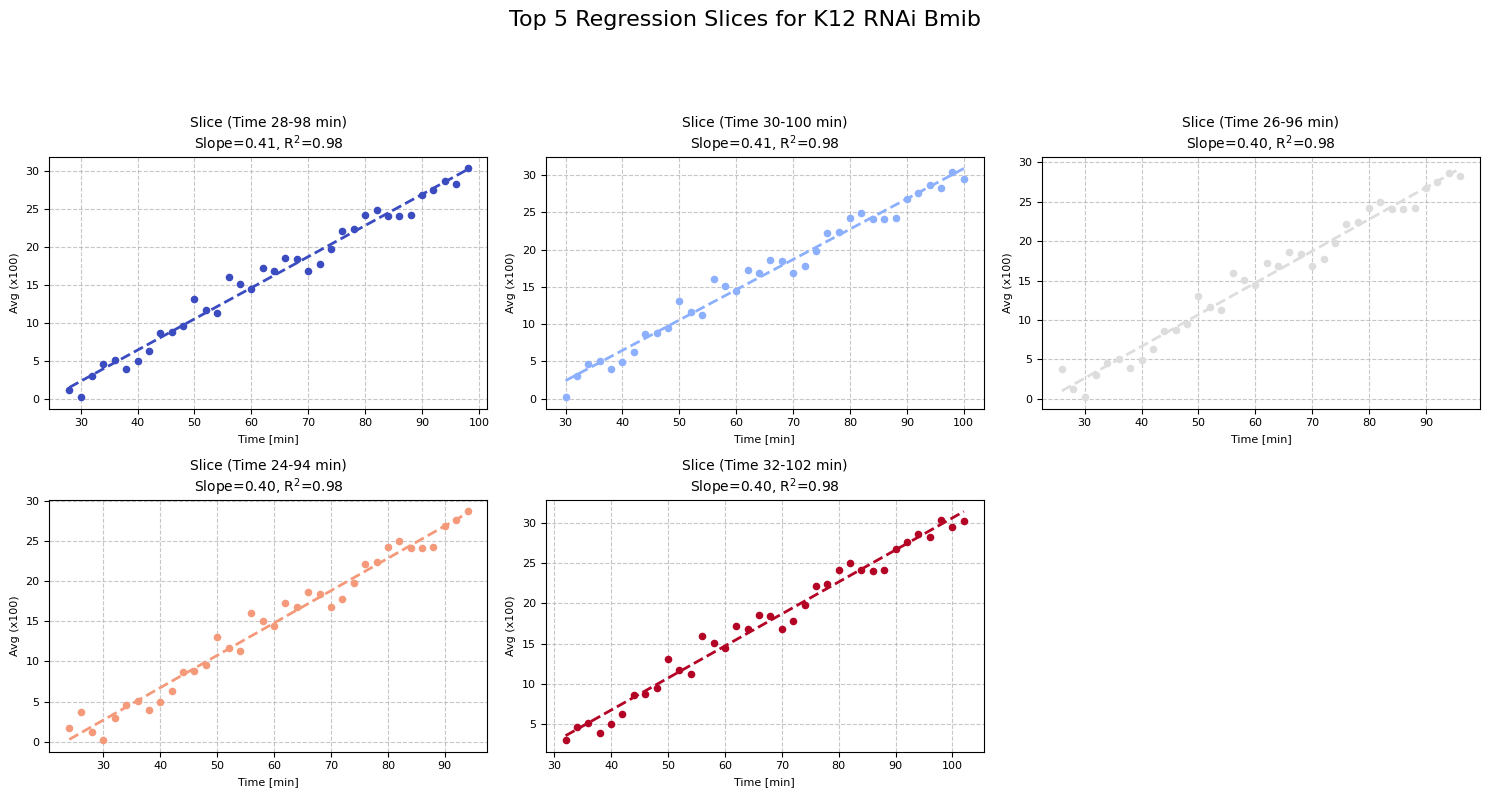

In [55]:
#@title Zoomed-in View of Top 5 Regression Slices for Each Replicate Group
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats
import re
import matplotlib.cm as cm # Ensure cm is imported for colormaps

# Ensure df_regression_summary_sorted and df_summary_stats_multiindex are available
if 'df_regression_summary_sorted' not in locals() or df_regression_summary_sorted.empty:
    print("Error: df_regression_summary_sorted is not available or is empty. Please run the previous cells.")
elif 'df_summary_stats_multiindex' not in locals() or df_summary_stats_multiindex.empty:
    print("Error: df_summary_stats_multiindex is not available or is empty. Please run the previous cells.")
else:
    # Get a list of all unique replicate groups
    all_replicate_groups = df_summary_stats_multiindex.columns.get_level_values(0).unique()
    if 'Time [min]' in all_replicate_groups:
        all_replicate_groups = all_replicate_groups.drop('Time [min]')

    # Iterate through each replicate group to create a figure with subplots for its top 5 slices
    for base_rep in all_replicate_groups:
        # Filter the sorted summary for the current group and take the top 5
        top_5_slices_for_group = df_regression_summary_sorted[
            df_regression_summary_sorted['Replicate Group'] == base_rep
        ].head(5)

        if not top_5_slices_for_group.empty:
            num_slices = len(top_5_slices_for_group)
            # Determine subplot grid size. Max 5 slices, so a 2x3 or 3x2 layout might be good.
            # Let's go for a flexible layout, e.g., if 5 slices, 2x3 grid, one empty spot.
            # If num_slices is 1 or 2, 1x2; 3 or 4, 2x2; 5, 2x3.
            if num_slices == 1:
                ncols = 1
                nrows = 1
            elif num_slices == 2:
                ncols = 2
                nrows = 1
            elif num_slices == 3 or num_slices == 4:
                ncols = 2
                nrows = 2
            else: # num_slices == 5
                ncols = 3
                nrows = 2

            fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(5 * ncols, 4 * nrows))
            # Flatten axes array for easy iteration, especially if nrows or ncols is 1
            axes = axes.flatten() if isinstance(axes, np.ndarray) else np.array([axes])

            fig.suptitle(f'Top 5 Regression Slices for {base_rep}', fontsize=16, y=1.02)

            # Generate a colormap for distinct colors for the slices within this group
            # This is consistent with how slices were colored in the overall graph (k7bDQzkzu0sL)
            slice_colors = cm.get_cmap('coolwarm', num_slices)

            for i, (index, row) in enumerate(top_5_slices_for_group.iterrows()):
                if i >= len(axes): # Safety break if more slices than subplots allocated (e.g., dynamic calculation)
                    break

                ax = axes[i]

                slice_label = row['Slice']
                slope_from_summary = row['Slope']
                r_squared_from_summary = row['R-squared']

                # Extract start and end time from slice_label
                time_match = re.search(r'Time (\d+)-(\d+) min', slice_label)
                if time_match:
                    start_time = int(time_match.group(1))
                    end_time = int(time_match.group(2))
                else:
                    print(f"Warning: Could not parse slice time range from label '{slice_label}'. Skipping subplot.")
                    continue

                # Ensure 'Time [min]' in df_summary_stats_multiindex is numeric
                df_summary_stats_multiindex['Time [min]'] = pd.to_numeric(df_summary_stats_multiindex['Time [min]'], errors='coerce')

                # Filter df_summary_stats_multiindex to get the data for the selected slice
                slice_data_for_plot = df_summary_stats_multiindex[
                    (df_summary_stats_multiindex['Time [min]'] >= start_time) &
                    (df_summary_stats_multiindex['Time [min]'] <= end_time)
                ].copy()

                x_data = slice_data_for_plot['Time [min]'].astype(float)
                y_data = slice_data_for_plot[(base_rep, 'Avg (x100)')].astype(float)

                if len(x_data) < 2 or len(y_data) < 2:
                    ax.text(0.5, 0.5, f"Not enough data for {slice_label}", horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
                    ax.set_title(slice_label)
                    continue

                # Recalculate regression for the exact slice data for plotting accuracy
                slope, intercept, r_value, p_value, std_err = stats.linregress(x_data, y_data)
                r_squared = r_value**2

                # Generate the best-fit line
                x_fit = np.array([x_data.min(), x_data.max()])
                y_fit = slope * x_fit + intercept

                # Get the color for this specific slice, consistent with the overall plot
                current_color = slice_colors(i / num_slices)

                # Plot data points with the assigned color
                ax.scatter(x_data, y_data, color=current_color, s=20, zorder=5)
                # Plot regression line with the assigned color
                ax.plot(x_fit, y_fit, color=current_color, linestyle='--', linewidth=2, zorder=4)

                ax.set_title(f'{slice_label}\nSlope={slope:.2f}, R$^2$={r_squared:.2f}', fontsize=10)
                ax.set_xlabel('Time [min]', fontsize=8)
                ax.set_ylabel('Avg (x100)', fontsize=8)
                ax.grid(True, linestyle='--', alpha=0.7)
                ax.tick_params(axis='both', which='major', labelsize=8)

            # Hide any unused subplots
            for j in range(i + 1, len(axes)):
                fig.delaxes(axes[j])

            plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent title overlap
            plt.show()
        else:
            print(f"No top 5 slices to display for Replicate Group: {base_rep}")

In [ ]:
#@title Choose a slice to display the plot

import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd
import numpy as np # Make sure numpy is imported for np.array
import re # Make sure re is imported for re.search

# Ensure df_regression_summary and df_summary_stats_multiindex are available
if 'df_regression_summary' not in locals() or df_regression_summary.empty:
    print("Error: df_regression_summary is not available or is empty. Please run the previous cell.")
else:
    # Removed: print("Available regression summaries:")
    # Removed: display(df_regression_summary.style.format({'R-squared': '{:.4f}', 'Slope': '{:.4f}'}))

    while True:
        try:
            row_num_input = input(f"\nEnter the row number (index) from the summary table to plot (0 to {len(df_regression_summary) - 1}): ")
            row_index = int(row_num_input)
            if 0 <= row_index < len(df_regression_summary):
                break
            else:
                print("Invalid row number. Please enter an index within the displayed range.")
        except ValueError:
            print("Invalid input. Please enter an integer.")

    # Get the selected regression result row
    selected_row = df_regression_summary.iloc[row_index]

    slice_label = selected_row['Slice']
    replicate_group = selected_row['Replicate Group']
    r_squared_from_summary = selected_row['R-squared']
    slope_from_summary = selected_row['Slope']

    print(f"\nPreparing plot for: {replicate_group}, {slice_label}")

    # Extract start and end time from slice_label to filter df_summary_stats_multiindex
    time_match = re.search(r'Time (\d+)-(\d+) min', slice_label)
    if time_match:
        start_time = int(time_match.group(1))
        end_time = int(time_match.group(2))
    else:
        # Fallback if regex fails, or if 'points_per_slice' was 1, leading to 0-0 or similar
        print("Could not parse slice time range from label. Using full data range for Time [min].")
        start_time = df_summary_stats_multiindex['Time [min]'].min()
        end_time = df_summary_stats_multiindex['Time [min]'].max()

    # Filter df_summary_stats_multiindex to get the data for the selected slice
    # Ensure 'Time [min]' in df_summary_stats_multiindex is numeric for comparison
    df_summary_stats_multiindex['Time [min]'] = pd.to_numeric(df_summary_stats_multiindex['Time [min]'], errors='coerce')

    slice_data_for_plot = df_summary_stats_multiindex[
        (df_summary_stats_multiindex['Time [min]'] >= start_time) &
        (df_summary_stats_multiindex['Time [min]'] <= end_time)
    ].copy()

    x_data = slice_data_for_plot['Time [min]'].astype(float)
    y_data = slice_data_for_plot[(replicate_group, 'Avg (x100)')].astype(float) # Use the scaled column name

    if len(x_data) < 2 or len(y_data) < 2:
        print(f"Error: Not enough data points to plot or perform regression for the selected slice and group.")
    else:
        # Recalculate regression for the exact slice data (to ensure fit line is accurate)
        slope, intercept, r_value, p_value, std_err = stats.linregress(x_data, y_data)
        r_squared = r_value**2

        # Generate the best-fit line
        x_fit = np.array([x_data.min(), x_data.max()])
        y_fit = slope * x_fit + intercept

        plt.figure(figsize=(10, 6))

        # Plot original data points
        plt.scatter(x_data, y_data, label=f'{replicate_group} Data', color='blue', s=50, zorder=5)

        # Plot best-fit line
        plt.plot(x_fit, y_fit, color='red', linestyle='--', label=f'Best-Fit Line')

        # Add equation and R-squared to the title
        title_str = f'{replicate_group} - {slice_label}\nEquation: y = {slope:.4f}x + {intercept:.4f} ($R^2$ = {r_squared:.4f})'
        plt.title(title_str)
        plt.xlabel('Time [min]')
        plt.ylabel('Average of Sample (x100)') # Keep y-axis label consistent
        plt.legend()
        plt.grid(True)
        plt.show()

Available Replicate Groups: ['K12 RNAi Bmib']
Enter the Replicate Group name to plot (e.g., 'CB 15'): K12 RNAi Bmib

Plotting top 5 regression slices for K12 RNAi Bmib:
  - Processing: K12 RNAi Bmib, Slice (Time 28-98 min)
  - Processing: K12 RNAi Bmib, Slice (Time 30-100 min)
  - Processing: K12 RNAi Bmib, Slice (Time 26-96 min)
  - Processing: K12 RNAi Bmib, Slice (Time 24-94 min)
  - Processing: K12 RNAi Bmib, Slice (Time 32-102 min)


/tmp/ipykernel_691/895125337.py:42: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap('coolwarm', len(top_5_slices_for_group))


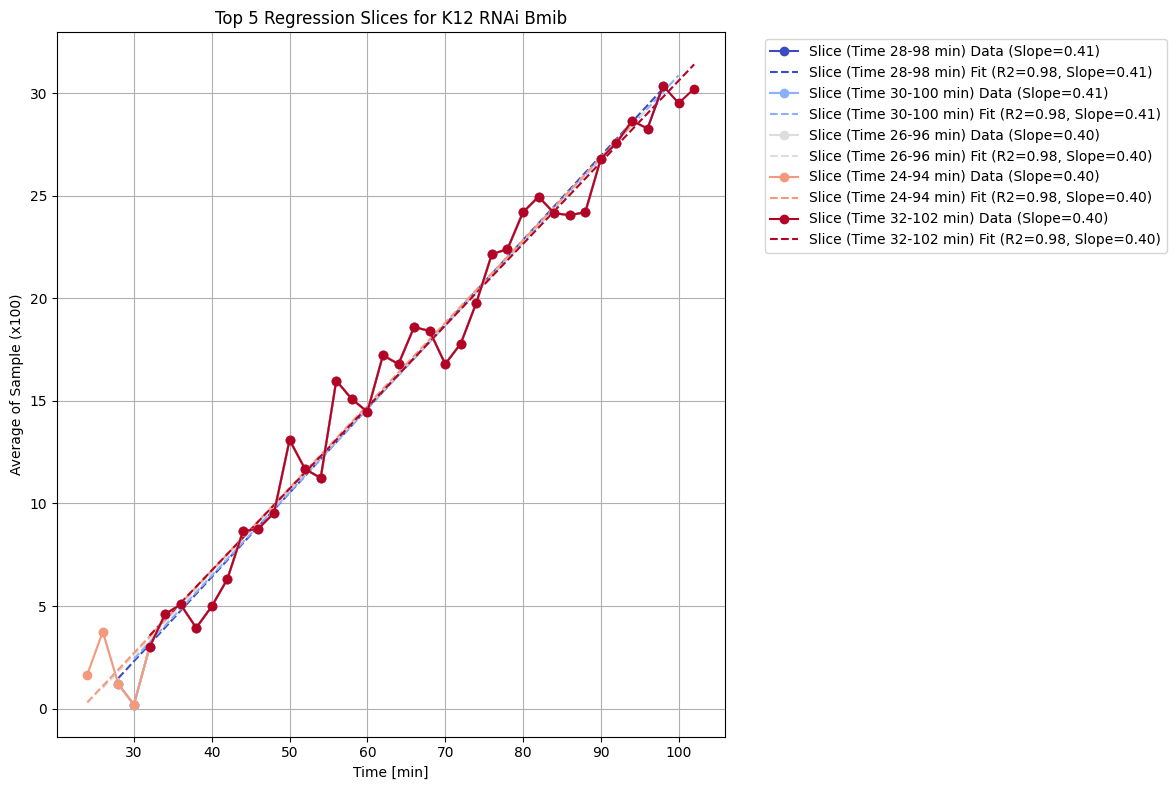

In [56]:
#@title Plot top 5 regression slices for a user-specified sample (combined plot)

import matplotlib.pyplot as plt
from scipy import stats
import pandas as pd
import numpy as np
import re
import matplotlib.cm as cm

# Ensure df_regression_summary_sorted and df_summary_stats_multiindex are available
if 'df_regression_summary_sorted' not in locals() or df_regression_summary_sorted.empty:
    print("Error: df_regression_summary_sorted is not available or is empty. Please run the previous cells.")
else:
    # Get list of unique replicate groups from the sorted summary
    available_groups = df_regression_summary_sorted['Replicate Group'].unique().tolist()
    print("Available Replicate Groups:", available_groups)

    while True:
        user_group_input = input("Enter the Replicate Group name to plot (e.g., 'CB 15'): ")
        if user_group_input in available_groups:
            break
        else:
            print(f"Invalid Replicate Group. Please choose from {available_groups}")

    # Filter the sorted summary for the chosen group and take the top 5
    top_5_slices_for_group = df_regression_summary_sorted[
        df_regression_summary_sorted['Replicate Group'] == user_group_input
    ].head(5)

    if top_5_slices_for_group.empty:
        print(f"No regression results found for Replicate Group: {user_group_input}")
    else:
        print(f"\nPlotting top 5 regression slices for {user_group_input}:")

        plt.figure(figsize=(12, 8))
        plt.title(f'Top 5 Regression Slices for {user_group_input}')
        plt.xlabel('Time [min]')
        plt.ylabel('Average of Sample (x100)')
        plt.grid(True)

        # Get a colormap for distinct colors (changed from 'viridis' to 'coolwarm' for consistency)
        colors = cm.get_cmap('coolwarm', len(top_5_slices_for_group))

        for i, (index, row) in enumerate(top_5_slices_for_group.iterrows()):
            slice_label = row['Slice']
            replicate_group = row['Replicate Group']
            # r_squared_from_summary = row['R-squared'] # Not directly used in plot title anymore
            # slope_from_summary = row['Slope'] # Not directly used in plot title anymore

            print(f"  - Processing: {replicate_group}, {slice_label}")

            # Extract start and end time from slice_label to filter df_summary_stats_multiindex
            time_match = re.search(r'Time (\d+)-(\d+) min', slice_label)
            if time_match:
                start_time = int(time_match.group(1))
                end_time = int(time_match.group(2))
            else:
                print(f"Warning: Could not parse slice time range from label '{slice_label}'. Using full data range for Time [min].")
                start_time = df_summary_stats_multiindex['Time [min]'].min()
                end_time = df_summary_stats_multiindex['Time [min]'].max()

            # Ensure 'Time [min]' in df_summary_stats_multiindex is numeric for comparison
            df_summary_stats_multiindex['Time [min]'] = pd.to_numeric(df_summary_stats_multiindex['Time [min]'], errors='coerce')

            # Filter df_summary_stats_multiindex to get the data for the selected slice
            slice_data_for_plot = df_summary_stats_multiindex[
                (df_summary_stats_multiindex['Time [min]'] >= start_time) &
                (df_summary_stats_multiindex['Time [min]'] <= end_time)
            ].copy()

            x_data = slice_data_for_plot['Time [min]'].astype(float)
            y_data = slice_data_for_plot[(replicate_group, 'Avg (x100)')].astype(float)

            if len(x_data) < 2 or len(y_data) < 2:
                print(f"Error: Not enough data points to plot or perform regression for the selected slice {slice_label} and group {replicate_group}.")
            else:
                # Recalculate regression for the exact slice data for plotting accuracy
                slope, intercept, r_value, p_value, std_err = stats.linregress(x_data, y_data)
                r_squared = r_value**2

                # Generate the best-fit line
                x_fit = np.array([x_data.min(), x_data.max()])
                y_fit = slope * x_fit + intercept

                # Plot original data points with connecting lines
                current_color = colors(i / len(top_5_slices_for_group))
                plt.plot(x_data, y_data, marker='o', linestyle='-', color=current_color, label=f'{slice_label} Data (Slope={slope:.2f})', zorder=5)

                # Plot best-fit line
                plt.plot(x_fit, y_fit, color=current_color, linestyle='--', label=f'{slice_label} Fit (R2={r_squared:.2f}, Slope={slope:.2f})')

        plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left') # Place legend outside the plot
        plt.tight_layout() # Adjust layout to prevent legend overlap
        plt.show()

In [ ]:
#@title Normalized Slope Bar Plot for Top Slice per Replicate Group (What is the default value we need to normalized)
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Ensure df_regression_summary_sorted is available from previous steps
if 'df_regression_summary_sorted' not in locals() or df_regression_summary_sorted.empty:
    print("Error: df_regression_summary_sorted is not available or is empty. Please run the previous cells that generate it.")
else:
    # Get the entry with the highest slope for each unique Replicate Group
    # Since df_regression_summary_sorted is already sorted by Slope (descending) within each group,
    # we can use nlargest(1) to get the top entry for each group.
    df_top_slopes_per_group = df_regression_summary_sorted.groupby('Replicate Group', group_keys=False).apply(lambda x: x.nlargest(1, 'Slope')).reset_index(drop=True)

    # Find the N2 15 reference slope for normalization
    n2_15_reference_data = df_top_slopes_per_group[
        df_top_slopes_per_group['Replicate Group'] == 'N2 DMSO' # Modify HERE 🔧
    ]

    if n2_15_reference_data.empty:
        print("Error: 'N2 15' reference group not found in the regression summary. Cannot perform normalization.")
    else:
        # Ensure we take the *single* highest slope for N2 15, in case there were multiple N2 15 groups somehow
        n2_15_reference_data = n2_15_reference_data.sort_values(by='Slope', ascending=False).iloc[0]

        n2_15_ref_slope = n2_15_reference_data['Slope']
        n2_15_ref_slice_label = n2_15_reference_data['Slice']
        n2_15_ref_group = n2_15_reference_data['Replicate Group']

        if n2_15_ref_slope == 0:
            print("Error: The reference 'N2 15' slope is zero. Cannot perform normalization. Please check your data.")
        else:
            # Prepare a list to store data for the bar plot
            plot_data = []

            # Add the dynamically selected top samples, normalized by the 'N2 15' reference slope
            for index, row in df_top_slopes_per_group.iterrows():
                current_group = row['Replicate Group']
                current_slice = row['Slice']
                current_slope = row['Slope']

                normalized_slope = current_slope / n2_15_ref_slope

                plot_data.append({
                    'Sample Label': f"{current_group} ({current_slice})",
                    'Original Slope': current_slope,
                    'Normalized Slope': normalized_slope
                })

            # Create a DataFrame from the prepared plot data
            df_bar_plot = pd.DataFrame(plot_data)

            # Create the bar plot
            plt.figure(figsize=(12, 7))

            # Define colors for the bars - all will be 'skyblue'
            colors = ['skyblue'] * len(df_bar_plot)

            bars = plt.bar(df_bar_plot['Sample Label'], df_bar_plot['Normalized Slope'], color=colors)

            plt.xlabel('Sample and Slice')
            plt.ylabel(f'Normalized Slope (Relative to {n2_15_ref_group} {n2_15_ref_slice_label})')
            plt.title('Normalized Slopes for Top Slices of Each Sample Group')
            plt.xticks(rotation=45, ha='right') # Rotate x-axis labels for better readability
            plt.grid(axis='y', linestyle='--', alpha=0.7)
            plt.tight_layout() # Adjust layout to prevent labels from overlapping
            plt.show()

            print("\nOriginal and Normalized Slope Values:")
            display(df_bar_plot.style.format({'Original Slope': '{:.4f}', 'Normalized Slope': '{:.4f}'}))